# Transfer Learning for Computer Vision Tutorial

In this tutorial, you will learn how to train a convolutional neural network for image classification using transfer learning.

These two major transfer learning scenarios look as follows:

- **Finetuning the ConvNet**: Instead of random initialization, we initialize the network with a pretrained network, like the one that is trained on imagenet 1000 dataset. Rest of the training looks as usual.

- **ConvNet as fixed feature extractor**: Here, we will freeze the weights for all of the network except that of the final fully connected layer. This last fully connected layer is replaced with a new one with random weights and only this layer is trained.

In [1]:
# License: BSD
# Author: Sasank Chilamkurthy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True
plt.ion()   # interactive mode

## Load Data

We will use `torchvision` and `torch.utils.data` packages for loading the data.

The problem we’re going to solve today is to train a model to classify `ants` and `bees`. We have about 120 training images each for `ants` and `bees`. There are 75 validation images for each class. Usually, this is a very small dataset to generalize upon, if trained from scratch. Since we are using transfer learning, we should be able to generalize reasonably well.

This dataset is a very small subset of imagenet.

In [2]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'data-sources/hymenoptera/'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

## Visualize a few images
Let’s visualize a few training images so as to understand the data augmentations.

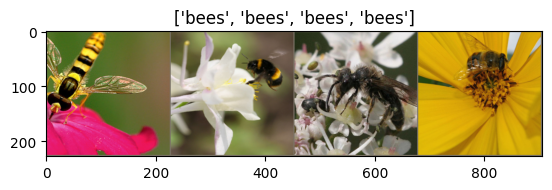

In [3]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

## Training the model

Now, let’s write a general function to train a model. Here, we will illustrate:

- Scheduling the learning rate
- Saving the best model

In the following, parameter `scheduler` is an `LR` scheduler object from `torch.optim.lr_scheduler`.

In [4]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

## Visualizing the model predictions
Generic function to display predictions for a few images

In [5]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

## Finetuning the ConvNet
Load a pretrained model and reset final fully connected layer.

In [6]:
model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to ``nn.Linear(num_ftrs, len(class_names))``.
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

### Train and evaluate
It should take around 15-25 min on CPU. On GPU though, it takes less than a minute.

In [7]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

Epoch 0/24
----------
train Loss: 0.5447 Acc: 0.7213
val Loss: 0.2659 Acc: 0.8889

Epoch 1/24
----------
train Loss: 0.5506 Acc: 0.7992
val Loss: 0.3264 Acc: 0.8889

Epoch 2/24
----------
train Loss: 0.5788 Acc: 0.7992
val Loss: 0.4947 Acc: 0.8170

Epoch 3/24
----------
train Loss: 0.6246 Acc: 0.7787
val Loss: 0.5183 Acc: 0.7908

Epoch 4/24
----------
train Loss: 0.6126 Acc: 0.7787
val Loss: 0.3097 Acc: 0.9150

Epoch 5/24
----------
train Loss: 0.4460 Acc: 0.8115
val Loss: 0.3197 Acc: 0.8693

Epoch 6/24
----------
train Loss: 0.3939 Acc: 0.8115
val Loss: 0.3365 Acc: 0.8824

Epoch 7/24
----------
train Loss: 0.3507 Acc: 0.8811
val Loss: 0.3201 Acc: 0.8954

Epoch 8/24
----------
train Loss: 0.3329 Acc: 0.8607
val Loss: 0.3149 Acc: 0.8954

Epoch 9/24
----------
train Loss: 0.2079 Acc: 0.9180
val Loss: 0.2778 Acc: 0.9085

Epoch 10/24
----------
train Loss: 0.2995 Acc: 0.8730
val Loss: 0.3094 Acc: 0.8889

Epoch 11/24
----------
train Loss: 0.4108 Acc: 0.8566
val Loss: 0.2804 Acc: 0.9020

Ep

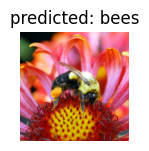

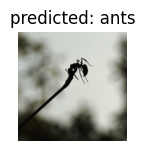

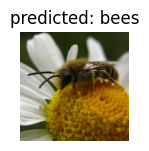

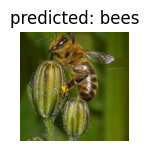

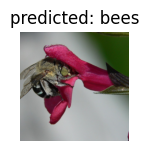

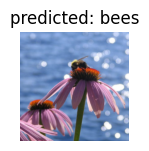

In [8]:
visualize_model(model_ft)

## ConvNet as fixed feature extractor

Here, we need to freeze all the network except the final layer. We need to set `requires_grad = False` to freeze the parameters so that the gradients are not computed in `backward()`.

In [9]:
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

### Train and evaluate
On CPU this will take about half the time compared to previous scenario. This is expected as gradients don’t need to be computed for most of the network. However, forward does need to be computed.

In [10]:
model_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.5297 Acc: 0.7213
val Loss: 0.2014 Acc: 0.9412

Epoch 1/24
----------
train Loss: 0.4434 Acc: 0.7787
val Loss: 0.1483 Acc: 0.9542

Epoch 2/24
----------
train Loss: 0.4821 Acc: 0.7992
val Loss: 0.4032 Acc: 0.8366

Epoch 3/24
----------
train Loss: 0.7255 Acc: 0.7131
val Loss: 0.4360 Acc: 0.8627

Epoch 4/24
----------
train Loss: 0.6837 Acc: 0.7459
val Loss: 0.4209 Acc: 0.8497

Epoch 5/24
----------
train Loss: 0.3973 Acc: 0.8074
val Loss: 0.4496 Acc: 0.8562

Epoch 6/24
----------
train Loss: 0.4586 Acc: 0.8074
val Loss: 0.1752 Acc: 0.9477

Epoch 7/24
----------
train Loss: 0.3934 Acc: 0.8279
val Loss: 0.1836 Acc: 0.9477

Epoch 8/24
----------
train Loss: 0.3468 Acc: 0.8361
val Loss: 0.1667 Acc: 0.9477

Epoch 9/24
----------
train Loss: 0.4395 Acc: 0.8033
val Loss: 0.2148 Acc: 0.9281

Epoch 10/24
----------
train Loss: 0.3067 Acc: 0.8730
val Loss: 0.1642 Acc: 0.9346

Epoch 11/24
----------
train Loss: 0.3448 Acc: 0.8443
val Loss: 0.2242 Acc: 0.9281

Ep

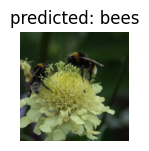

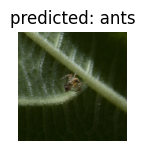

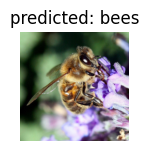

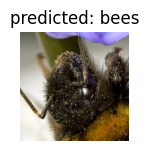

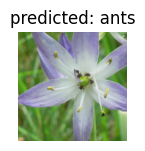

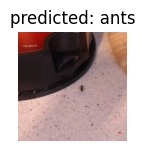

In [11]:
visualize_model(model_conv)

plt.ioff()
plt.show()

## Inference on custom images
Use the trained model to make predictions on custom images and visualize the predicted class labels along with the images.

In [12]:
def visualize_model_predictions(model,img_path):
    was_training = model.training
    model.eval()

    img = Image.open(img_path)
    img = data_transforms['val'](img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2,2,1)
        ax.axis('off')
        ax.set_title(f'Predicted: {class_names[preds[0]]}')
        imshow(img.cpu().data[0])

        model.train(mode=was_training)

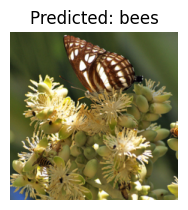

In [14]:
visualize_model_predictions(
    model_conv,
    img_path="data-sources/hymenoptera/val/bees/72100438_73de9f17af.jpg"
)

plt.ioff()
plt.show()

----------------------------